In [1]:
pip install xgboost lightgbm catboost lime joblib seaborn --break-system-packages


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 5.6 MB/s eta 0:00:18
    --------------------------------------- 2.1/100.2 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 3.4/100.2 MB 5.8 MB/s eta 0:00:17
   - -------------------------------------- 4.5/100.2 MB 5.7 MB/s eta 0:00:17
   -- ------------------------------------- 5.8/100.2 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 6.8/100.2 MB 5.8 MB/s eta 0:00:17
   --- ------------------------------------ 8.1/100.2 MB 5.9 MB/s eta 0:00:16
   --- ------------------------------------ 9.4/100.2

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import joblib

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Datase\Crop_recommendation.csv")

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['label'].value_counts())
df.describe()

Shape: (2200, 8)

Dtypes:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Class balance:
 label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


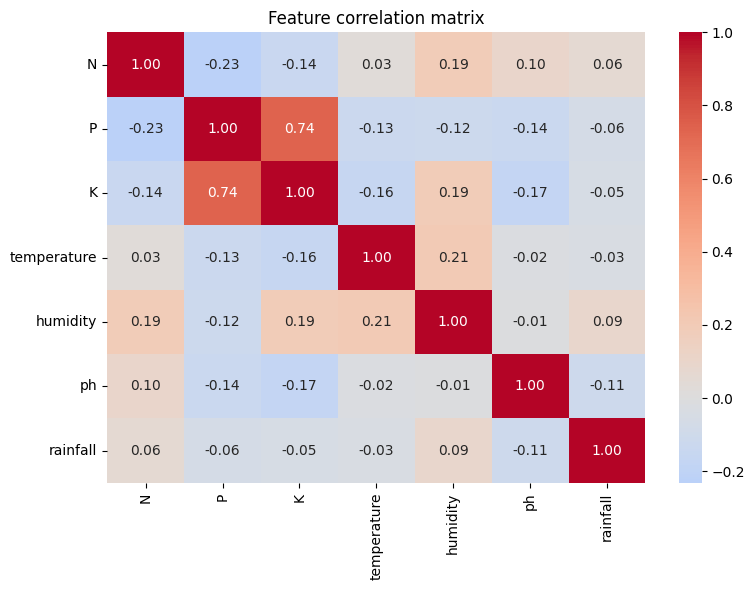

In [3]:
plt.figure(figsize=(8, 6))
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

Tranning

In [5]:
X = df[numeric_cols].copy()
y_raw = df['label'].copy()

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Classes:", len(class_names))

Train shape: (1760, 7) Test shape: (440, 7)
Classes: 22


#
Models

In [6]:
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "needs_scaling": True,
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "needs_scaling": True,
    },
    "SVM_RBF": {
        "model": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "needs_scaling": True,
    },
    "RandomForest": {
        "model": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "needs_scaling": False,
    },
    "GradientBoosting_sklearn": {
        "model": GradientBoostingClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "needs_scaling": False,
    },
    "XGBoost_GPU": {
        "model": xgb.XGBClassifier(
            n_estimators=300, tree_method="hist", device="cuda",
            random_state=RANDOM_STATE, eval_metric="mlogloss"
        ),
        "needs_scaling": False,
    },
    "LightGBM_GPU": {
        "model": lgb.LGBMClassifier(
            n_estimators=300, device="gpu", random_state=RANDOM_STATE, verbose=-1
        ),
        "needs_scaling": False,
    },
    "CatBoost_GPU": {
        "model": CatBoostClassifier(
            iterations=300, task_type="GPU", devices="0",
            random_state=RANDOM_STATE, verbose=False
        ),
        "needs_scaling": False,
    },
}

#

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import time
import os

# Optional: limit thread usage to avoid oversubscription
os.environ["OMP_NUM_THREADS"] = "1"

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, cfg in models.items():
    model = cfg["model"]
    Xtr = X_train_scaled if cfg["needs_scaling"] else X_train
    Xte = X_test_scaled if cfg["needs_scaling"] else X_test

    # Avoid joblib worker crashes / memory oversubscription
    n_jobs = 1

    t0 = time.time()

    cv_scores = cross_val_score(
        model,
        Xtr,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=n_jobs
    )

    model.fit(Xtr, y_train)

    train_time = time.time() - t0

    y_pred = model.predict(Xte)

    test_acc = accuracy_score(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results.append({
        "model": name,
        "cv_mean_acc": cv_scores.mean(),
        "cv_std_acc": cv_scores.std(),
        "test_acc": test_acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "train_time_sec": train_time,
    })

    cfg["fitted"] = model

    print(
        f"{name:28s} | "
        f"CV acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} "
        f"| Test acc: {test_acc:.4f} "
        f"| Time: {train_time:.2f}s"
    )


# Convert collected results into DataFrame
results_df = (
    pd.DataFrame(results)
    .sort_values("test_acc", ascending=False)
    .reset_index(drop=True)
)

results_df

LogisticRegression           | CV acc: 0.9682 ± 0.0066 | Test acc: 0.9727 | Time: 0.45s
KNN                          | CV acc: 0.9653 ± 0.0121 | Test acc: 0.9795 | Time: 0.13s
SVM_RBF                      | CV acc: 0.9795 ± 0.0107 | Test acc: 0.9841 | Time: 0.77s
RandomForest                 | CV acc: 0.9938 ± 0.0055 | Test acc: 0.9932 | Time: 4.17s
GradientBoosting_sklearn     | CV acc: 0.9858 ± 0.0040 | Test acc: 0.9886 | Time: 97.74s
XGBoost_GPU                  | CV acc: 0.9903 ± 0.0023 | Test acc: 0.9886 | Time: 28.20s
LightGBM_GPU                 | CV acc: 0.9920 ± 0.0038 | Test acc: 0.9886 | Time: 51.93s
CatBoost_GPU                 | CV acc: 0.9881 ± 0.0087 | Test acc: 0.9955 | Time: 21.12s


,model,cv_mean_acc,cv_std_acc,test_acc,macro_precision,macro_recall,macro_f1,train_time_sec
0,CatBoost_GPU,0.988068,0.008692,0.995455,0.995671,0.995455,0.995452,21.117583
1,RandomForest,0.993750,0.005509,0.993182,0.993506,0.993182,0.993178,4.169067
2,GradientBoosting_sklearn,0.985795,0.004018,0.988636,0.989571,0.988636,0.988674,97.738698
3,XGBoost_GPU,0.990341,0.002273,0.988636,0.989177,0.988636,0.988507,28.197480
4,LightGBM_GPU,0.992045,0.003769,0.988636,0.989374,0.988636,0.988559,51.928195
5,SVM_RBF,0.979545,0.010690,0.984091,0.985610,0.984091,0.984038,0.771809
6,KNN,0.965341,0.012106,0.979545,0.980356,0.979545,0.979283,0.128622
7,LogisticRegression,0.968182,0.006577,0.972727,0.974022,0.972727,0.972464,0.451599


In [15]:
print("Done")

Done


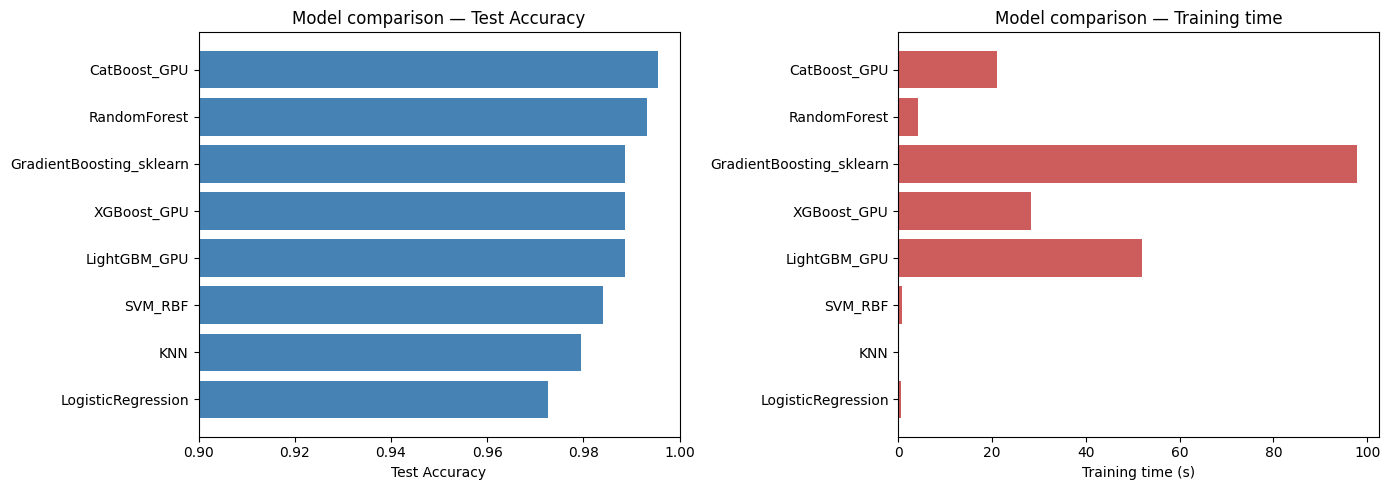

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df["model"], results_df["test_acc"], color="steelblue")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Model comparison — Test Accuracy")
axes[0].set_xlim(0.9, 1.0)
axes[0].invert_yaxis()

axes[1].barh(results_df["model"], results_df["train_time_sec"], color="indianred")
axes[1].set_xlabel("Training time (s)")
axes[1].set_title("Model comparison — Training time")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
best_name = results_df.iloc[0]["model"]
best_cfg = models[best_name]
best_model = best_cfg["fitted"]
Xte_best = X_test_scaled if best_cfg["needs_scaling"] else X_test

y_pred_best = best_model.predict(Xte_best)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

Best model: CatBoost_GPU

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
 

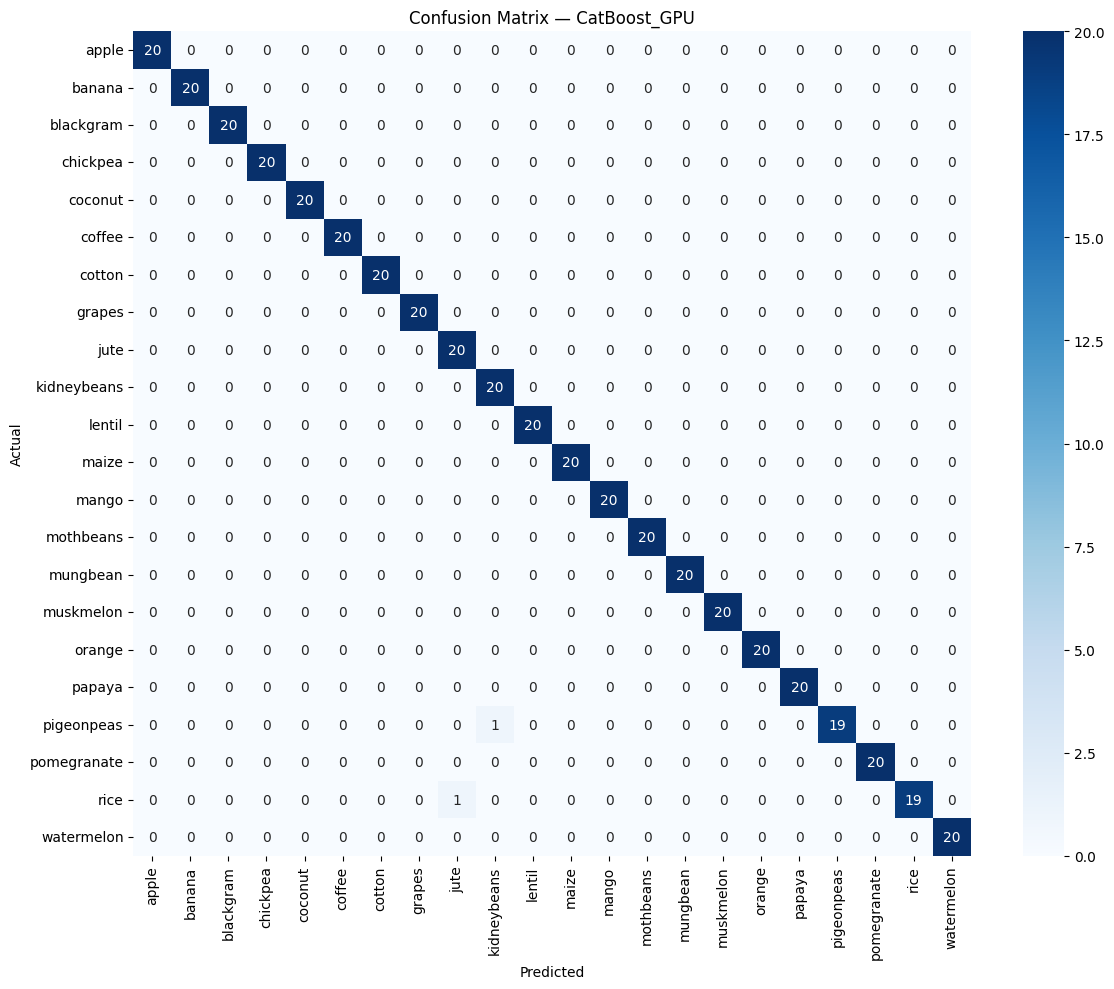

In [18]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

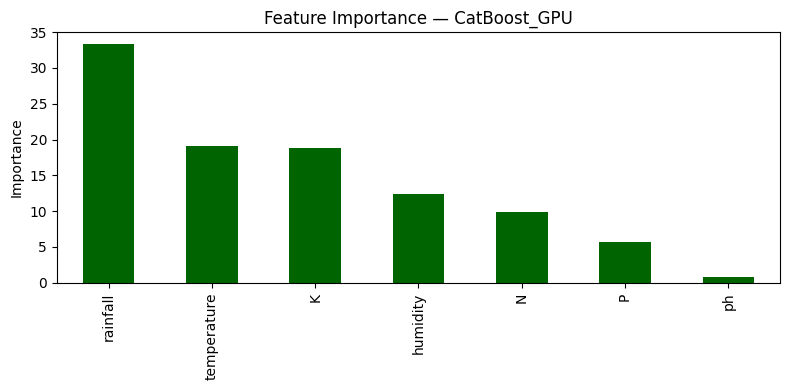

rainfall       33.346001
temperature    19.066502
K              18.774302
humidity       12.383139
N               9.898738
P               5.733373
ph              0.797945
dtype: float64


In [19]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=numeric_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    importances.plot(kind="bar", color="darkgreen")
    plt.title(f"Feature Importance — {best_name}")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    print(f"{best_name} does not expose feature_importances_ directly (e.g. SVM/KNN/LogReg).")

In [20]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values if not best_cfg["needs_scaling"] else X_train_scaled,
    feature_names=numeric_cols,
    class_names=class_names,
    mode="classification",
    random_state=RANDOM_STATE,
)

sample_idx = 0
sample = X_test.values[sample_idx] if not best_cfg["needs_scaling"] else X_test_scaled[sample_idx]
true_label = class_names[y_test[sample_idx]]

exp = explainer.explain_instance(
    sample,
    best_model.predict_proba,
    num_features=len(numeric_cols),
    top_labels=1,
)

print(f"True label: {true_label}")
predicted_class_idx = best_model.predict([sample])[0]
print(f"Predicted: {class_names[predicted_class_idx]}\n")
exp.show_in_notebook(show_table=True)

True label: orange
Predicted: ['orange']



In [21]:
joblib.dump(best_model, f"crop_recommendation_{best_name}.joblib")
joblib.dump(scaler, "crop_recommendation_scaler.joblib")
joblib.dump(le, "crop_recommendation_label_encoder.joblib")
results_df.to_csv("crop_recommendation_baseline_results.csv", index=False)

print(f"Saved: crop_recommendation_{best_name}.joblib")
print("Saved: crop_recommendation_scaler.joblib")
print("Saved: crop_recommendation_label_encoder.joblib")
print("Saved: crop_recommendation_baseline_results.csv")

Saved: crop_recommendation_CatBoost_GPU.joblib
Saved: crop_recommendation_scaler.joblib
Saved: crop_recommendation_label_encoder.joblib
Saved: crop_recommendation_baseline_results.csv
